# TASK 1 : PREPARING

### 1.1 -- Importing dataset

In [84]:
import numpy as np
import pandas as pd

# 1.1 -- Importing dataset
df = pd.read_csv("../data/synthetic_coffee_health_10000.csv")
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


### 1.2 -- Basic preparing of the dataset

In [85]:
# Removing empty data

df.isna().sum()

ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

In [86]:
for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col] = df[col].fillna(mode_val[0])

In [87]:
# Dataset types formatting

df.dtypes

ID                           int64
Age                          int64
Gender                         str
Country                        str
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality                  str
BMI                        float64
Heart_Rate                   int64
Stress_Level                   str
Physical_Activity_Hours    float64
Health_Issues                  str
Occupation                     str
Smoking                      int64
Alcohol_Consumption          int64
dtype: object

In [88]:
cols = ["Smoking", "Alcohol_Consumption"]
df[cols] = df[cols].astype(bool)
# we can skip loop for logical data type transform
# as boolean is correctly interpret from numeric 0 & 1
df.dtypes

ID                           int64
Age                          int64
Gender                         str
Country                        str
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality                  str
BMI                        float64
Heart_Rate                   int64
Stress_Level                   str
Physical_Activity_Hours    float64
Health_Issues                  str
Occupation                     str
Smoking                       bool
Alcohol_Consumption           bool
dtype: object

In [89]:
 # preview altered table
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Mild,Other,False,False
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Mild,Service,False,False
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,False,False
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,False,False
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,False,True
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,False,False
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,Mild,Student,True,True
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,Mild,Student,False,False


In [90]:
# Cleaning data from extreme values

df = df[
    (df["Age"].between(12, 130)) &
    (df["Heart_Rate"].between(40, 180)) &
    (df["Sleep_Hours"] < 24) &
    (df["BMI"].between(12, 60)) &
    (df["Caffeine_mg"] < 1200) # dangerous caffeine dose per day
]
df.shape[0] # shows 10000 -> all data was by default "clean"

10000

# TASK 2 : VISUAL DATA ANALYSIS

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
sns.set_theme(style="whitegrid")

### 2.1 -- One variable distribution

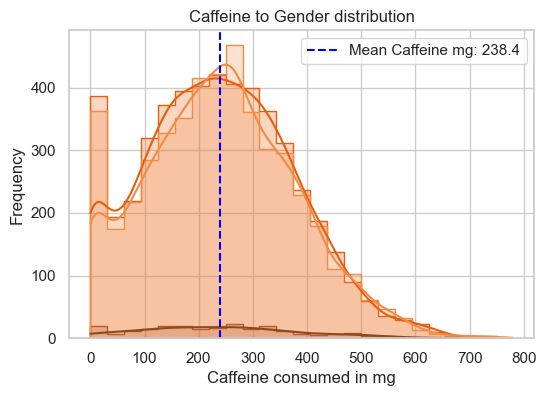

In [93]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Caffeine_mg", hue="Gender", kde=True, bins=25, palette="Oranges_d", element="step")
plt.axvline(df["Caffeine_mg"].mean(), color="blue", linestyle="--",
            label=f"Mean Caffeine mg: {df['Caffeine_mg'].mean():.1f}")
plt.title("Caffeine to Gender distribution")
plt.xlabel("Caffeine consumed in mg")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [94]:
df["Gender"].value_counts()

Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

_As we can see from the histogram there is almost no difference in caffeine consumption between Males & Females. In this plot we can also see the number of participants who has chosen the non-binary variant to observe their caffeine consumption which in general repeats the binary ones with its curve. The mode of the caffeine consumed is reaches inbetween 200 and 300, being closer to the 200 value and is marked by the red dashed line_

p### 2.2 -- Categories comparison

In [95]:
df["Health_Issues"].value_counts()

Health_Issues
Mild        9520
Moderate     463
Severe        17
Name: count, dtype: int64

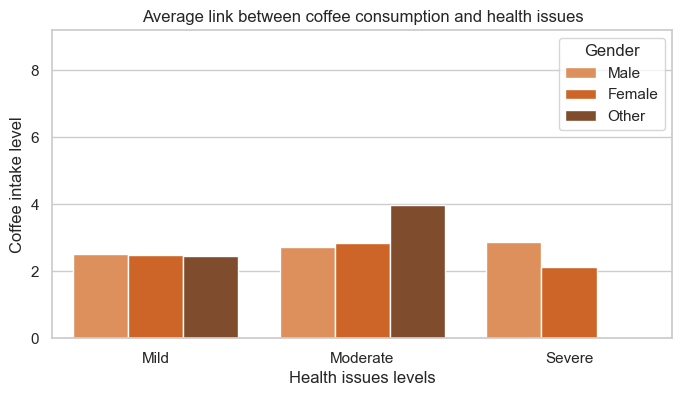

In [96]:
plt.figure(figsize=(8,4))
order = df["Health_Issues"].unique()

ax = sns.barplot(data=df, x="Health_Issues", y="Coffee_Intake", hue="Gender", order=order, palette="Oranges_d", errorbar=None)
plt.ylim(0, df["Coffee_Intake"].max() + 1) # better visual difference
plt.title("Average link between coffee consumption and health issues")
plt.xlabel("Health issues levels")
plt.ylabel("Coffee intake level")
plt.show()

_As we can see from this plot the average level of coffee consumed is quite the same for each level of health issues so that means there is nearly no effect of the consumed coffee to the illness development. There is the minor difference for the severe level that Males have around 3.0 coffee income (~300 mg) when Females have the 2.0 level. There is a minor increase in the moderate level where non-binary people take leadership and are 2 levels of the coffee consumed ahead (Binary ~ 2.0 , Non-binary > 4.0)_

### 2.3 -- Dispersion and emission analysis

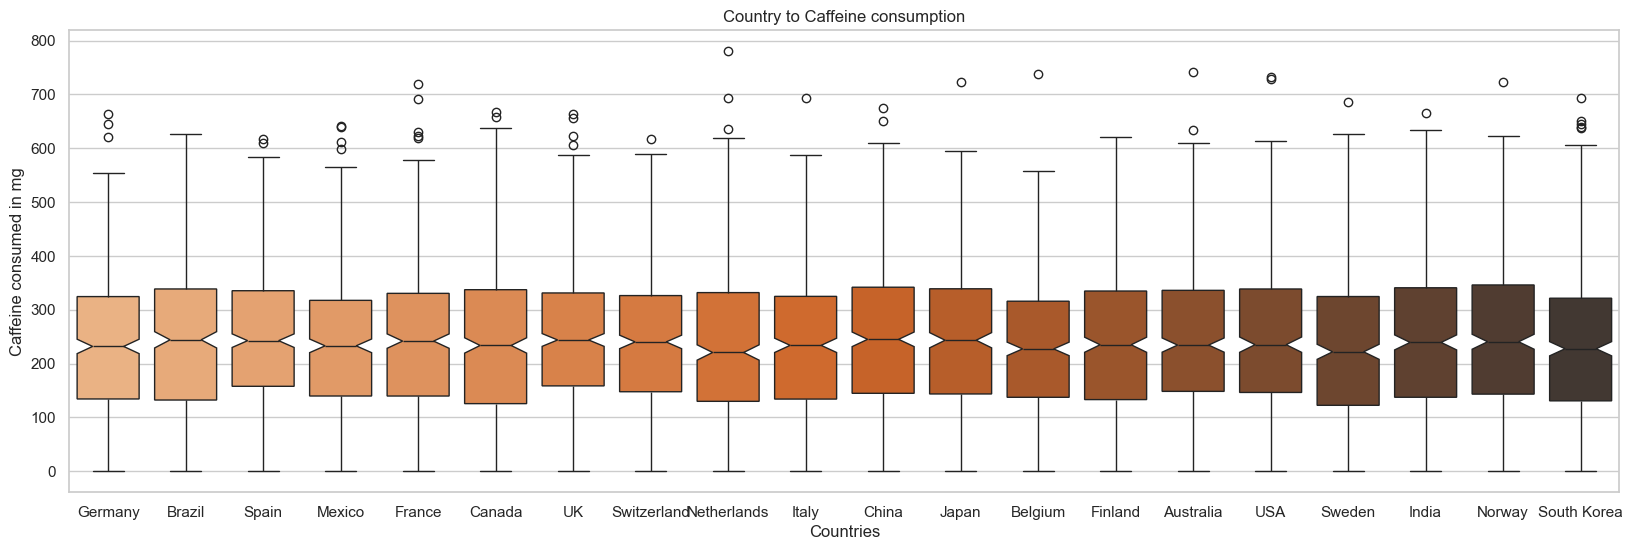

In [104]:
plt.figure(figsize=(20,6))
order = df["Country"].unique()

sns.boxplot(data=df, x="Country", y="Caffeine_mg", hue="Country", order=order, palette="Oranges_d", notch=True)
plt.title("Country to Caffeine consumption")
plt.xlabel("Countries")
plt.ylabel("Caffeine consumed in mg")
plt.show()